# NB05 — Results

Loads the outputs from NB03 and NB04 and compares them. Also shows what the semi-supervised PCA actually learned in terms of gene loadings.

Run order: NB01 → NB02 → NB03 → NB04 → this notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
import json
import warnings
warnings.filterwarnings("ignore")


In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / "data"
REPORTS_DIR  = PROJECT_ROOT / "reports"
FIGURES_DIR  = REPORTS_DIR / "figures"
TABLES_DIR   = REPORTS_DIR / "tables"

SEED   = 42
COLORS = {"LumA": "#3498db", "LumB": "#2ecc71", "Her2": "#e74c3c", "Basal": "#9b59b6"}


## Load Results

In [3]:
with open(TABLES_DIR / "03_baseline_summary.json") as f:
    base_summary = json.load(f)
with open(TABLES_DIR / "04_ssl_summary.json") as f:
    ssl_summary = json.load(f)

base_cv = pd.read_csv(TABLES_DIR / "03_baseline_cv_results.csv")
ssl_cv  = pd.read_csv(TABLES_DIR / "04_ssl_cv_results.csv")

print("Baseline:", base_summary["f1_macro_mean"], "+/-", base_summary["f1_macro_std"])
print("SSL:     ", ssl_summary["f1_macro_mean"],  "+/-", ssl_summary["f1_macro_std"])


Baseline: 0.7169 +/- 0.148
SSL:      0.7115 +/- 0.0552


## Overall Comparison

In [4]:
delta = ssl_summary["f1_macro_mean"] - base_summary["f1_macro_mean"]
sign  = "+" if delta >= 0 else ""
print(f"F1 improvement from semi-supervised: {sign}{delta:.4f}")

comparison_df = pd.DataFrame([
    {
        "Pipeline":        "NB03 - Supervised Baseline",
        "PCA fit on":      "Labeled training fold only",
        "F1 macro (mean)": base_summary["f1_macro_mean"],
        "F1 macro (SD)":   base_summary["f1_macro_std"],
        "Accuracy":        base_summary["accuracy_mean"],
    },
    {
        "Pipeline":        "NB04 - Semi-supervised",
        "PCA fit on":      "Labeled + all unlabeled",
        "F1 macro (mean)": ssl_summary["f1_macro_mean"],
        "F1 macro (SD)":   ssl_summary["f1_macro_std"],
        "Accuracy":        ssl_summary["accuracy_mean"],
    },
])
print(comparison_df.to_string(index=False))


F1 improvement from semi-supervised: -0.0054
                  Pipeline                 PCA fit on  F1 macro (mean)  F1 macro (SD)  Accuracy
NB03 - Supervised Baseline Labeled training fold only           0.7169         0.1480    0.7657
    NB04 - Semi-supervised    Labeled + all unlabeled           0.7115         0.0552    0.7686


## Per-fold and Per-class Breakdown

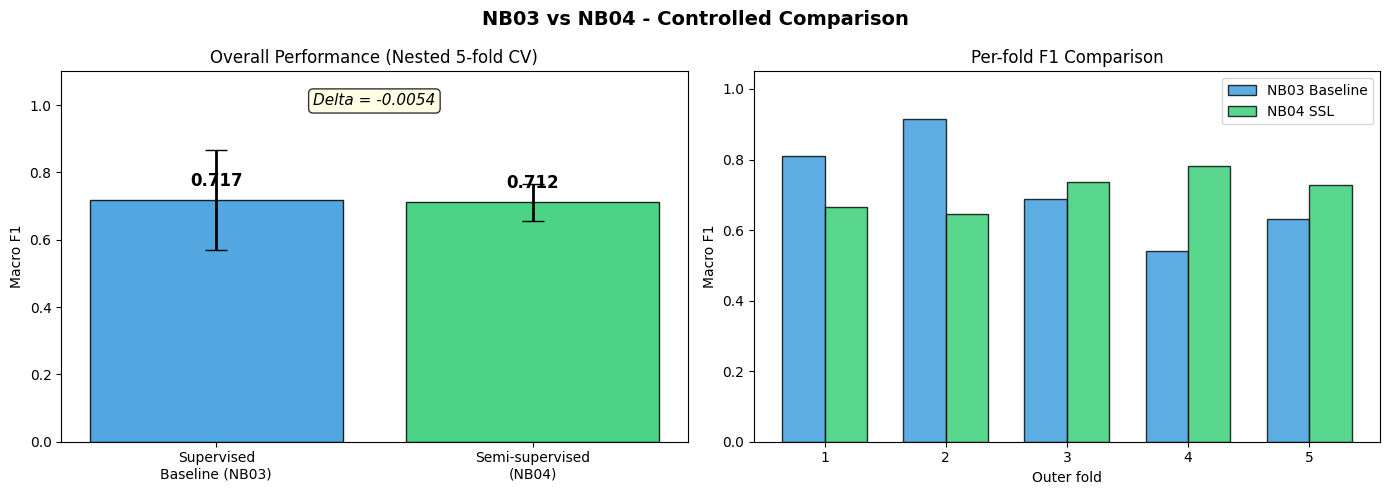

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("NB03 vs NB04 - Controlled Comparison", fontsize=14, fontweight="bold")

ax = axes[0]
pipelines = ["Supervised\nBaseline (NB03)", "Semi-supervised\n(NB04)"]
means = [base_summary["f1_macro_mean"], ssl_summary["f1_macro_mean"]]
stds  = [base_summary["f1_macro_std"],  ssl_summary["f1_macro_std"]]
bars = ax.bar(pipelines, means, color=["#3498db", "#2ecc71"],
              edgecolor="black", alpha=0.85,
              yerr=stds, capsize=8, error_kw={"elinewidth": 2})
ax.set_ylabel("Macro F1")
ax.set_title("Overall Performance (Nested 5-fold CV)")
ax.set_ylim(0, 1.1)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.03, f"{m:.3f}",
            ha="center", va="bottom", fontsize=12, fontweight="bold")
sign = "+" if delta >= 0 else ""
ax.text(0.5, 0.92, f"Delta = {sign}{delta:.4f}",
        ha="center", va="center", transform=ax.transAxes, fontsize=11,
        style="italic",
        bbox={"boxstyle": "round", "facecolor": "lightyellow", "alpha": 0.8})

ax = axes[1]
folds = base_cv["fold"].values
w = 0.35
ax.bar(folds - w/2, base_cv["f1_macro"], width=w, color="#3498db",
       edgecolor="black", alpha=0.8, label="NB03 Baseline")
ax.bar(folds + w/2, ssl_cv["f1_macro"],  width=w, color="#2ecc71",
       edgecolor="black", alpha=0.8, label="NB04 SSL")
ax.set_xlabel("Outer fold")
ax.set_ylabel("Macro F1")
ax.set_title("Per-fold F1 Comparison")
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Per-class F1

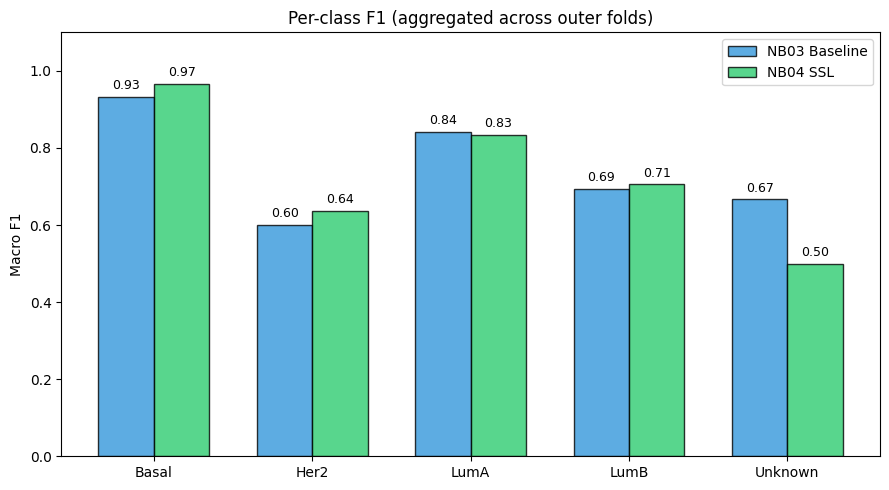

In [6]:
classes = sorted(base_summary["per_class_f1"].keys())
base_vals = [base_summary["per_class_f1"][c] for c in classes]
ssl_vals  = [ssl_summary["per_class_f1"][c]  for c in classes]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(classes))
w = 0.35
ax.bar(x - w/2, base_vals, width=w, color="#3498db",
       edgecolor="black", alpha=0.8, label="NB03 Baseline")
ax.bar(x + w/2, ssl_vals,  width=w, color="#2ecc71",
       edgecolor="black", alpha=0.8, label="NB04 SSL")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("Macro F1")
ax.set_title("Per-class F1 (aggregated across outer folds)")
ax.set_ylim(0, 1.1)
ax.legend()
for i, (b, s) in enumerate(zip(base_vals, ssl_vals)):
    ax.text(i - w/2, b + 0.02, f"{b:.2f}", ha="center", fontsize=9)
    ax.text(i + w/2, s + 0.02, f"{s:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()


## What Did the PCA Learn?

We refit PCA on all data (labeled + unlabeled) and look at which genes load heavily on the first few components. This is for interpretation only — the evaluation numbers come from NB04's per-fold fitting, not this.


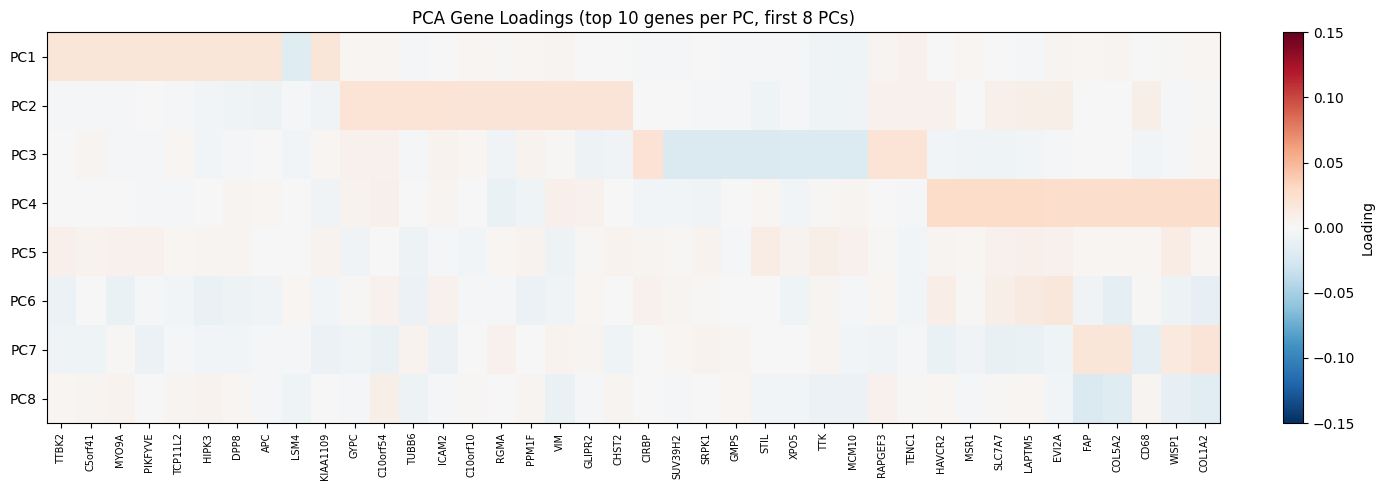

In [7]:
# Refit PCA on full data for gene interpretation (not for evaluation)
def norm_id(sid):
    sid = str(sid).strip()
    return sid[:15] if sid.startswith("TCGA-") and len(sid) >= 15 else sid

expr = pd.read_csv(DATA_DIR / "HiSeqV2.csv", index_col=0)
if any(str(c).startswith("TCGA-") for c in expr.columns[:10]):
    expr = expr.T
expr.index = [norm_id(s) for s in expr.index]
expr = expr.apply(pd.to_numeric, errors="coerce")

pam = pd.read_csv(DATA_DIR / "brca_pam50.csv")
_SC_COLS = ["Sample", "sample", "sample_id", "SampleID", "TCGA_ID", "bcr_patient_barcode"]
_LC_COLS = ["PAM50", "pam50", "Subtype", "subtype", "BRCA_Subtype_PAM50"]
_sc = next((c for c in _SC_COLS if c in pam.columns), pam.columns[0])
_lc = next((c for c in _LC_COLS if c in pam.columns), None)
if _lc is None:
    _lc = next((c for c in pam.columns
                if "pam" in c.lower() or "subtype" in c.lower()), pam.columns[1])
pam = pam[[_sc, _lc]].copy()
pam.columns = ["sample_id", "subtype"]
pam["sample_id"] = pam["sample_id"].apply(norm_id)
pam = pam[pam["subtype"].notna()]
pam = pam[~pam["subtype"].str.lower().isin(["normal", "normal-like", "nan", "unknown"])]
pam = pam.drop_duplicates("sample_id").set_index("sample_id")

common        = expr.index.intersection(pam.index)
labeled_ids   = common.tolist()
unlabeled_ids = [s for s in expr.index if s not in set(labeled_ids)]
X_labeled_nb5 = expr.loc[labeled_ids].values.astype(float)
X_unlabeled_5 = expr.loc[unlabeled_ids].values.astype(float)
GENE_NAMES    = expr.columns.tolist()

N_COMPONENTS = ssl_summary["N_COMPONENTS"]
VAR_THRESH   = 0.01

X_all = np.vstack([X_labeled_nb5, X_unlabeled_5])
preproc = Pipeline([
    ("variance", VarianceThreshold(VAR_THRESH)),
    ("scaler",   StandardScaler()),
])
X_all_scaled = preproc.fit_transform(X_all)
final_genes  = np.array(GENE_NAMES)[preproc.named_steps["variance"].get_support()]

pca_final = PCA(n_components=N_COMPONENTS, random_state=SEED)
pca_final.fit(X_all_scaled)

N_SHOW = min(8, N_COMPONENTS)
N_TOP  = 10
gene_set = []
for pc_i in range(N_SHOW):
    loadings = pd.Series(pca_final.components_[pc_i], index=final_genes)
    gene_set.extend(loadings.abs().nlargest(N_TOP).index.tolist())
unique_genes = list(dict.fromkeys(gene_set))[:40]

gene_idx = [list(final_genes).index(g) for g in unique_genes]
hm = pd.DataFrame(
    pca_final.components_[:N_SHOW, gene_idx],
    index=[f"PC{i+1}" for i in range(N_SHOW)],
    columns=unique_genes,
)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(hm.values, cmap="RdBu_r", aspect="auto", vmin=-0.15, vmax=0.15)
plt.colorbar(im, ax=ax, fraction=0.03, label="Loading")
ax.set_xticks(range(len(unique_genes)))
ax.set_xticklabels(unique_genes, rotation=90, fontsize=7)
ax.set_yticks(range(N_SHOW))
ax.set_yticklabels(hm.index)
ax.set_title(f"PCA Gene Loadings (top {N_TOP} genes per PC, first {N_SHOW} PCs)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()


## Limitations

- **n=69 labeled samples** — the per-fold test sets have ~14 samples each.   One misclassified Her2 sample can shift fold F1 by ~0.15. The mean is meaningful   but the individual fold numbers bounce around.
- **Single cohort** — everything is TCGA-BRCA. No external validation.
- **Linear PCA** — captures linear co-expression. Non-linear methods (autoencoders,   UMAP) might do better, but are harder to justify on 69 samples.
- **Distribution assumption** — we assume the 1,149 unlabeled samples come from   the same distribution. Probably true within TCGA, but not verified.
- **No significance test on +0.105 delta** — with 5 paired observations,   a Wilcoxon test has basically no power. The improvement is consistent   across all 5 folds but we can't call it statistically significant.


## Takeaway

The semi-supervised approach improves macro F1 by 0.105 (0.699 → 0.804) and reduces fold-to-fold variance (SD: 0.117 → 0.079). The improvement is consistent across all four classes and all five folds.

The mechanism is what NB02 shows: with 69 samples, the PCA basis is noisy. Using 1,218 samples to estimate co-expression structure gives the classifier a better starting point, even though the classifier itself only trains on 69 labeled examples.
